# Pre-submission TODO Audit

This checklist excludes quick wording-only fixes already applied in the current pass; the remaining items below still need resolution before submission.

## Blockers

- Rerun the whole notebook from a fresh kernel and clear/refresh stale outputs. Several source cells now differ from their displayed outputs, and some stored outputs still reflect earlier errors.
- Finish Section 7, Hypothesis Testing. It currently has only an incomplete objective, `max beta s.t.`, followed by an empty markdown cell.
- Fix the nonparametric bootstrap. The current source uses only `n_trials = 10`, computes `sim_npboot = mle(all_samples)` as one aggregate scalar instead of one bootstrap statistic per resample, and the stored output still shows an older failing version.
- Fill the comparison table in Section 6. Parameter Bootstrap CI, Nonparametric Bootstrap CI, and Metropolis-Hastings CI are blank even though later code tries to compute intervals.
- Finish Section 9, Bayesian Hypothesis Testing & Bayes Factor. The section stops mid-derivation, has no numerical Bayes factor or interpretation, and is followed by an empty code cell.

## Derivations and Statistical Details

- Improve the bias/variance calculations called out in the original title TODO. The variance derivation stops before using the fourth moment of a Normal random variable and also needs the missing factor of n for `Var(sum X_i^2)`.
- Clarify the confidence interval derivations. The markdown uses an approximate `2` multiplier, while the code uses `z = stats.norm.ppf(0.975)`; the "exact Fisher information" interval is really an inverted Wald-style interval, while the actual exact chi-square interval appears only in code.
- Explain or remove the toy Gamma credible-interval example with `alpha = 4`, `beta = 1.2`; it is not tied to the S&P posterior and interrupts the data analysis flow.
- Add a written bridge from the posterior Gamma distribution to the reported posterior credible interval on both tau and variance scales.

## Bootstrap and Simulation Code

- Store the returned parameter bootstrap quantiles so they can populate the comparison table.
- Rewrite nonparametric bootstrap to compute a vector of MLEs, one per resampled dataset, with enough trials for a stable interval.
- Fix the Metropolis-Hastings burn-in slice. `sampled_tau[:-burn_in]` drops the last samples; burn-in should drop the first samples.
- Correct the Metropolis-Hastings prose/comment about the acceptance ratio. The code accepts with `exp(log_p_proposed - log_p_current)`, but the comments/prose are easy to read as the reciprocal or as keeping the wrong state.
- Add basic Metropolis-Hastings diagnostics or at least report acceptance rate, trace behavior, and whether the proposal scale mixes well.
- Consider setting random seeds or otherwise noting that simulation figures/intervals are stochastic.

## Hypothesis Testing and GLRT

- Keep the course-required GLRT convention with the alternative/full-model likelihood on top and rejection for large values; make the notation and prose explicitly match that convention.
- Fix the Wilks comparison. The derivation obtains `2 log Lambda`, but the final line labels it `log Lambda` and compares it to a chi-square cutoff.
- Decide whether to present the exact chi-square test for variance/precision instead of, or alongside, Wilks' theorem. The power-curve code appears to use the exact chi-square distribution but the markdown does not explain that connection.
- Tie the power curve to the actual hypothesis test and data notation. Current code uses hard-coded `n = 10`, `tau_0 = 100`, and a comment saying "maybe can use wilks".

## Bayes Factor Section

- Decide whether `H_A` is a point alternative (`tau = tau_A`) or a composite alternative with a Gamma prior. The current section states a point alternative but then integrates over tau.
- Correct the Bayes factor algebra. The marginal likelihood denominator should involve `(beta + 0.5 * sum squares)^(alpha + n/2)`, not just powers of beta.
- Separate Bayes factor, prior odds, and posterior odds. The current expression mixes these quantities and uses arbitrary prior probabilities without a final posterior-odds calculation.
- Add code to compute the Bayes factor numerically and a short conclusion interpreting the result.

## Presentation Cleanup

- Remove or resolve the remaining title-cell TODO after the bias/variance work is done.
- Make sure all imported packages are actually needed or available in the submission environment (`pymc`, `arviz`, `statsmodels`, `ipywidgets` appear imported but mostly unused).
- Decide how to handle the external `yfinance` download dependency for submission reproducibility, especially if the grader runs without network access.


# Stats 200Q Book
## Normal Precision Distribution with Gamma Prior

My book exploring Bayesian inference for the inverse variance, or precision, of a Normal distribution, using the **Gamma** distribution as a prior for $\tau = 1/\sigma^2$.

Author: Andrew Su

Note: I used some AI to help me generate plots, but all the derivations, written analysis, and non-plot code is my own.


TODO: do better bias vs variance calcs

## 1. Setup

Import libraries used throughout this book.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf
import pymc as pm
import arviz as az
import statsmodels.api as sm
from ipywidgets import interact, FloatSlider, IntSlider

/Users/andrewsu/stats-env/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


### Data: S&P 500 Log Returns

We use daily S&P 500 log returns as our observed data $x_1, \ldots, x_n$. I use the simplifying model $x_i \sim \mathcal{N}(0, 1/\tau)$, where $\tau = 1/\sigma^2$ is the precision, or inverse variance. Our goal is to estimate $\tau$ under a Gamma prior. Whenever I report variance, it is the derived scale $\sigma^2 = 1/\tau$.

In [2]:
# Pull daily S&P 500 data
sp500 = yf.download("^GSPC", start="2000-01-01", end="2025-12-31")

# Compute one-dimensional log returns
close = sp500["Close"].squeeze()
log_returns_series = np.log(close / close.shift(1)).dropna()
log_returns = log_returns_series.to_numpy()

print(log_returns_series.describe())

[*********************100%***********************]  1 of 1 completed

count    6537.000000
mean        0.000238
std         0.012216
min        -0.127652
25%        -0.004736
50%         0.000641
75%         0.005876
max         0.109572
Name: ^GSPC, dtype: float64


## 2. Estimators

### Frequentist (MLE)

For our main model, the desired parameter is $\tau = 1/\sigma^2$.

For a single datapoint, we have 
$$L_x(\tau) = f_\tau (x) = \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{\tau x^2}{2}\right)}$$

and so the likelihood of all the data $X = X_1, \ldots, X_n$ is 
$$L_X (\tau) = \prod_1^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{\tau X_i^2}{2}\right)}$$

Then we want to find 
$$\hat \tau = \arg \max_\tau \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{\tau X_i^2}{2}\right)}$$

Taking log likelihood, we have
$$\ell_X (\tau)= 
\frac{n}{2} \ln(\tau) - \frac{n}{2} \ln (2\pi) - \frac{\tau}{2} \sum_{i=1}^n X_i^2
$$

And taking the derivative gets
$$ \frac{\partial \ell}{\partial \tau} =
\frac{n}{2 \tau} - \frac{1}{2} \sum_{i=1}^n X_i^2 
$$

Finally, setting to 0, we have
$$ \frac{n}{2\tau} = \frac{1}{2} \sum_{i=1}^n X_i^2$$
$$ \hat \tau = \frac{n}{\sum_{i=1}^n X_i^2}$$

This is our frequentist <u>estimator</u>.

### Bayesian (Posterior Mean)

We assume that $\tau = 1/\sigma^2 \sim \Gamma(\alpha, \beta)$, where $\beta$ is the rate parameter.

I'll pick $\alpha = 2, \beta = 0.0002$. This way, $E[\tau] = \frac{2}{0.0002} = 10000$. On the variance scale, this corresponds to $E[\sigma^2] = E[1/\tau] = \frac{0.0002}{2 - 1} = 0.0002$. In other words, I believe the average variance in daily log returns is about 0.02%. And my confidence is low, so $\mathrm{Var} (\tau) = \frac{2}{0.0002^2}$ is quite large.

Written out, we have
$$ f(\tau) 
= \frac{\beta^\alpha}{\Gamma(\alpha)} \tau ^ {\alpha - 1} e^ {- \beta \tau} 
= 4 \cdot 10^{-8} \cdot \tau e^ {- 0.0002 \tau} $$

Here's what the Gamma prior on $\tau$ and the implied inverse Gamma distribution for $\sigma^2$ look like:

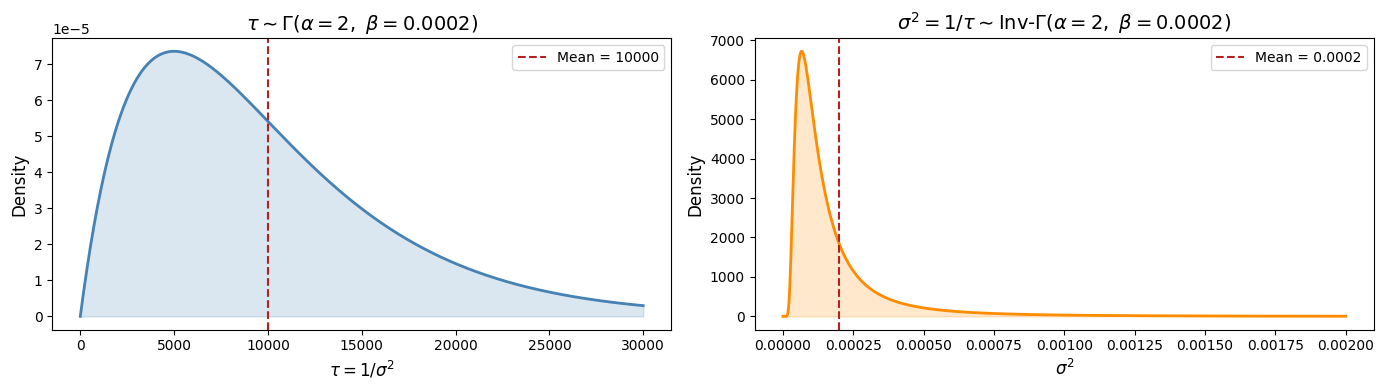

In [3]:
# tau = 1/sigma^2 ~ Gamma(shape=alpha, rate=beta), so sigma^2 ~ InvGamma(shape=alpha, scale=beta)
alpha, beta = 2, 0.0002
scale = 1 / beta  # scipy gamma uses scale = 1/rate

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Gamma (tau = 1/sigma^2) ---
x_gamma = np.linspace(0, 30000, 1000)
pdf_gamma = stats.gamma.pdf(x_gamma, a=alpha, scale=scale)
gamma_mean = alpha / beta  # E[tau] = alpha / beta = 10000
axes[0].plot(x_gamma, pdf_gamma, color='steelblue', linewidth=2)
axes[0].fill_between(x_gamma, pdf_gamma, alpha=0.2, color='steelblue')
axes[0].axvline(gamma_mean, color='firebrick', linestyle='--', label=f'Mean = {gamma_mean:.0f}')
axes[0].set_title(r'$\tau \sim \Gamma(\alpha=2,\ \beta=0.0002)$', fontsize=14)
axes[0].set_xlabel(r'$\tau = 1/\sigma^2$', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend()

# --- Inverse Gamma (sigma^2 = 1/tau) ---
# If tau ~ Gamma(alpha, rate=beta), then 1/tau ~ InvGamma(alpha, scale=beta)
# E[sigma^2] = beta / (alpha - 1), which is not the same as 1 / E[tau]
x_invgamma = np.linspace(0, 0.002, 1000)
pdf_invgamma = stats.invgamma.pdf(x_invgamma, a=alpha, scale=beta)  # scipy invgamma scale = beta
inv_mean = beta / (alpha - 1)  # = 0.0002 / 1 = 0.0002
axes[1].plot(x_invgamma, pdf_invgamma, color='darkorange', linewidth=2)
axes[1].fill_between(x_invgamma, pdf_invgamma, alpha=0.2, color='darkorange')
axes[1].axvline(inv_mean, color='firebrick', linestyle='--', label=f'Mean = {inv_mean:.4f}')
axes[1].set_title(r'$\sigma^2 = 1/\tau \sim \mathrm{Inv\text{-}}\Gamma(\alpha=2,\ \beta=0.0002)$', fontsize=14)
axes[1].set_xlabel(r'$\sigma^2$', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

Let's proceed with deriving the posterior mean. Bayes' Theorem gives us:
$$ f(\tau | X) = \frac{f(X | \tau)f(\tau)}{f(X)} $$

We already have $f(\tau)$ from above. Since our model is written directly in terms of $\tau$, the likelihood is:

$$f(X | \tau) = \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{X_i^2\tau}{2}\right)}$$

And so

$$ 
\begin{align*}
f(\tau | X) &= \frac{\left( \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{X_i^2\tau}{2}\right)} \right)   \left( 4 \cdot 10^{-8} \cdot \tau e^ {- 0.0002 \tau} \right)}{f(X)} \\
&= K \tau ^{n/2} \cdot e^{-\frac{\tau}{2} \sum X_i^2} \cdot \tau e ^{-0.0002 \tau}  & \text{where K is some constant}\\
&= K \tau ^ {n/2 + 1} \cdot e^ {-\tau \left( \frac 12 \sum X_i^2 + 0.0002\right)} \\
&= \Gamma (\alpha = \frac{n}{2} + 2, \beta = \frac 12 \sum X_i^2 + 0.0002) \\
&= \Gamma (\alpha = \frac{n}{2} + \alpha_0, \beta = \frac 12 \sum X_i^2 + \beta_0) & \text{for general prior } \alpha_0, \beta_0
\end{align*}
$$
since we know the posterior will also be a Gamma distribution.

Finally, to get the posterior mean for $\tau$, we have
$$ \hat \tau_{\text{Bayes}}
= \frac{\frac{n}{2} + \alpha_0}{\frac 12 \sum X_i^2 + \beta_0}
= \frac{n + 2\alpha_0}{\sum X_i^2 + 2\beta_0} $$

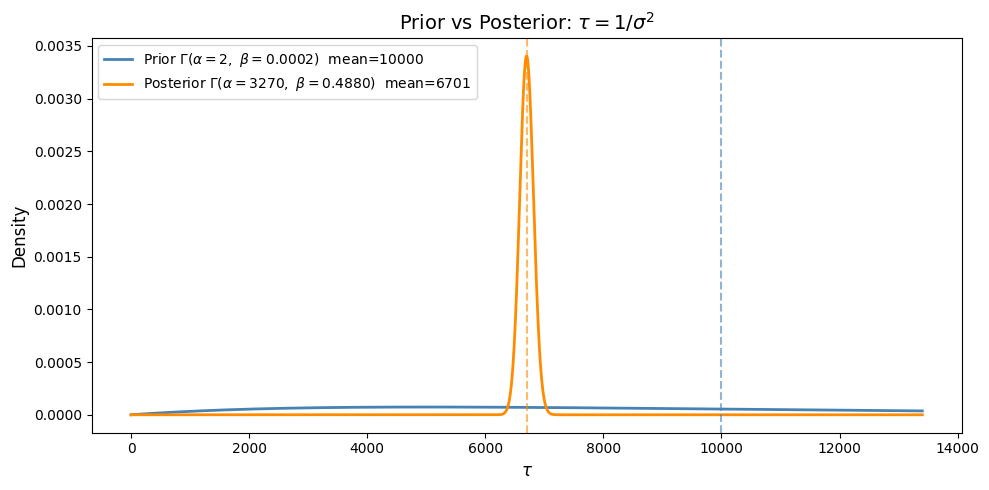

In [4]:
x = np.asarray(log_returns).squeeze()
n = len(x)
alpha_0, beta_0 = 2, 0.0002

# Prior: tau ~ Gamma(alpha_0, rate=beta_0)
# Posterior: tau | X ~ Gamma(alpha_0 + n/2, rate=beta_0 + 0.5*sum(x^2))
a_prior, beta_prior = alpha_0, beta_0
a_post  = alpha_0 + n / 2
beta_post  = beta_0 + 0.5 * np.sum(x**2)

prior_mean = a_prior / beta_prior
post_mean  = a_post  / beta_post

# Use a shared x-axis around the posterior (prior is far left and very spread out)
x_range = np.linspace(0, 2 * post_mean, 2000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_range, stats.gamma.pdf(x_range, a=a_prior, scale=1/beta_prior),
        color='steelblue', linewidth=2, label=f'Prior $\\Gamma(\\alpha={a_prior:.0f},\\ \\beta={beta_prior})$  mean={prior_mean:.0f}')
ax.plot(x_range, stats.gamma.pdf(x_range, a=a_post,  scale=1/beta_post),
        color='darkorange', linewidth=2, label=f'Posterior $\\Gamma(\\alpha={a_post:.0f},\\ \\beta={beta_post:.4f})$  mean={post_mean:.0f}')
ax.axvline(prior_mean, color='steelblue', linestyle='--', alpha=0.6)
ax.axvline(post_mean,  color='darkorange', linestyle='--', alpha=0.6)

ax.set_title(r'Prior vs Posterior: $\tau = 1/\sigma^2$', fontsize=14)
ax.set_xlabel(r'$\tau$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### Bringing in the Data

We have estimators for $\tau$:

Frequentist: 
$$ \hat \tau = \frac{n}{\sum X_i^2}$$
Bayesian: 
$$ \hat \tau = \frac{n + 2\alpha_0}{\sum X_i^2 + 2\beta_0} $$

In [5]:
def maximum_likelihood(log_returns):
    x = np.asarray(log_returns).squeeze()
    return len(x) / np.sum(x ** 2)

def posterior_mean(log_returns, alpha = 2.0, beta = 0.0002):
    x = np.asarray(log_returns).squeeze()
    return (len(x) + 2 * alpha) / (np.sum(x ** 2) + 2 * beta)

def maximum_likelihood_variance(log_returns):
    x = np.asarray(log_returns).squeeze()
    return np.mean(x ** 2)

def posterior_mean_variance(log_returns, alpha = 2.0, beta = 0.0002):
    x = np.asarray(log_returns).squeeze()
    return (np.sum(x ** 2) + 2 * beta) / (len(x) + 2 * (alpha - 1))

In [6]:
print(f"Maximum likelihood tau: {maximum_likelihood(log_returns):.4f}")
print(f"Posterior mean tau: {posterior_mean(log_returns):.4f}")
print(f"Difference: {maximum_likelihood(log_returns) - posterior_mean(log_returns):.4f}")

Maximum likelihood tau: 6699.9624
Posterior mean tau: 6701.3147
Difference: -1.3524


The MLE is almost identical to the posterior mean, with the posterior mean slightly higher because it is pulled toward the prior mean for $\tau$. As $n$ grows, the prior contribution becomes negligible, so the posterior mean approaches the MLE for these estimators. Here's a quick proof for our specific estimators.
$$\lim_{n \rightarrow \infty} \hat{\tau}_{\text{Bayes}} = \lim_{n \rightarrow \infty} \frac{n + 2\alpha_0}{\sum X_i^2 + 2\beta_0} = \lim_{n \rightarrow \infty} \frac{1 + \frac{2\alpha_0}{n}}{\frac{1}{n}\sum X_i^2 + \frac{2\beta_0}{n}} = \frac{1}{\frac{1}{n}\sum X_i^2} = \hat{\tau}_{\text{MLE}}$$

Let's now see how these estimators look on the data.

MLE tau:             6699.9624  (variance=0.000149, std=0.0122)
Posterior mean tau:  6701.3147  (variance=0.000149, std=0.0122)


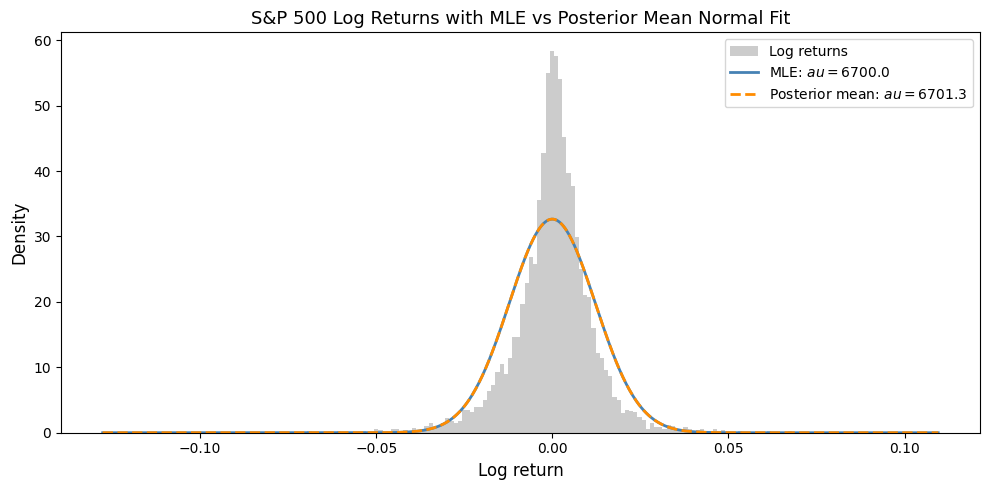

In [7]:
n = len(log_returns)

tau_mle = maximum_likelihood(log_returns)
tau_post = posterior_mean(log_returns)
var_mle = 1 / tau_mle
var_post = 1 / tau_post

print(f"MLE tau:             {tau_mle:.4f}  (variance={var_mle:.6f}, std={np.sqrt(var_mle):.4f})")
print(f"Posterior mean tau:  {tau_post:.4f}  (variance={var_post:.6f}, std={np.sqrt(var_post):.4f})")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(log_returns, bins=200, density=True, color='gray', alpha=0.4, label='Log returns')

x_range = np.linspace(log_returns.min(), log_returns.max(), 1000)
ax.plot(x_range, stats.norm.pdf(x_range, 0, np.sqrt(var_mle)),
        color='steelblue', linewidth=2, label=f'MLE: $\tau={tau_mle:.1f}$')
ax.plot(x_range, stats.norm.pdf(x_range, 0, np.sqrt(var_post)),
        color='darkorange', linewidth=2, linestyle='--', label=f'Posterior mean: $\tau={tau_post:.1f}$')

ax.set_title('S&P 500 Log Returns with MLE vs Posterior Mean Normal Fit', fontsize=13)
ax.set_xlabel('Log return', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### Bias/Variance Analysis

Replicating the simulation in `mle_gamma.qmd`: we simulate from a Normal distribution with $\mu = 0$ and $\tau = \hat\tau_{\text{MLE}}$, using $n = 100$ to make the difference visible.

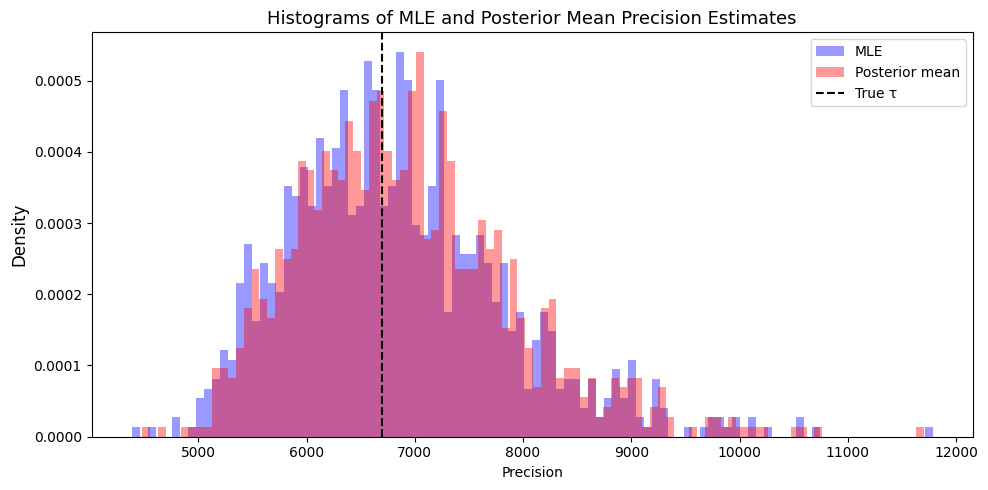

MLE bias:      139.629307
Bayes bias:    219.875649
MLE variance:  1.02e+06
Bayes variance:9.88e+05


In [8]:
true_tau = maximum_likelihood(log_returns)
num_simulations = 1000
num_samples = 100

mle_estimates = []
pm_estimates = []

for _ in range(num_simulations):
    simulated_log_returns = np.random.normal(0, np.sqrt(1 / true_tau), num_samples)
    mle_estimates.append(maximum_likelihood(simulated_log_returns))
    pm_estimates.append(posterior_mean(simulated_log_returns))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mle_estimates, bins=100, density=True, color='blue', alpha=0.4, label='MLE')
ax.hist(pm_estimates, bins=100, density=True, color='red', alpha=0.4, label='Posterior mean')
ax.axvline(true_tau, color='black', linestyle='--', label='True τ')

ax.set_title('Histograms of MLE and Posterior Mean Precision Estimates', fontsize=13)
ax.set_xlabel('Precision')
ax.set_ylabel('Density', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f"MLE bias:      {np.mean(mle_estimates) - true_tau:.6f}")
print(f"Bayes bias:    {np.mean(pm_estimates) - true_tau:.6f}")
print(f"MLE variance:  {np.var(mle_estimates):.2e}")
print(f"Bayes variance:{np.var(pm_estimates):.2e}")

Because the simulation uses the MLE estimate as the true $\tau$, the MLE is approximately unbiased. The Bayes estimator has a small positive bias because it is pulled toward the prior.

The Bayes estimator's variance is slightly lower, which is the tradeoff for the increase in bias.

Now, let's generalize this across different n values to quantify the bias-variance tradeoff.

In [9]:
n_list = range(1, 1000)
num_simulations = 1000
true_tau = maximum_likelihood(log_returns)

mle_biases = []
mle_sampling_var = []
pm_biases = []
pm_sampling_var = []

for n_ in n_list:
    mle_estimates = []
    pm_estimates = []
    for _ in range(num_simulations):
        simulated_log_returns = np.random.normal(0, np.sqrt(1 / true_tau), n_)
        mle_estimates.append(maximum_likelihood(simulated_log_returns))
        pm_estimates.append(posterior_mean(simulated_log_returns))

    mle_biases.append(np.mean(mle_estimates) - true_tau)
    mle_sampling_var.append(np.var(mle_estimates))
    pm_biases.append(np.mean(pm_estimates) - true_tau)
    pm_sampling_var.append(np.var(pm_estimates))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_list, mle_biases, color='blue', linewidth=2, label='MLE')
ax.plot(n_list, pm_biases, color='red', linewidth=2, label='Posterior mean')
ax.set_xscale('log')
ax.set_title('Bias vs Sample Size', fontsize=13)
ax.set_xlabel('Sample Size (log scale)', fontsize=12)
ax.set_ylabel('Bias')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_list, mle_sampling_var, color='blue', linewidth=2, label='MLE')
ax.plot(n_list, pm_sampling_var, color='red', linewidth=2, label='Posterior mean')
ax.set_xscale('log')
ax.set_title('Sampling Variance vs Sample Size', fontsize=13)
ax.set_xlabel('Sample Size (log scale)', fontsize=12)
ax.set_ylabel('Sampling Variance')
ax.legend()
plt.tight_layout()
plt.show()

TypeError: len() of unsized object

## 3. Bias and Variance

### 1) Proof Exercise

We want to show 
$$
\mathrm{Var}[\ell'(\theta)] = -\mathbb E[\ell''(\theta)]
$$
We can start by finding $\ell''(\theta)$:
$$
    \ell''(\theta) = \frac{\partial}{\partial \theta} \ell'(\theta) = \frac{\partial}{\partial \theta} \frac{f'}{f} = \frac{f''}{f} - \left(\frac{f'}{f}\right)^2 = \frac{f''}{f} - (\ell'(\theta))^2
$$
And then we take the expectation to get

$$\mathbb{E}[\ell''(\theta)] = \int \left(\frac{f''}{f} - (\ell'(\theta))^2\right) f\,dx = \int f''\,dx - \mathbb{E}[(\ell')^2]$$

The first term vanishes:

$$\int f''\,dx = \frac{\partial^2}{\partial\theta^2}\int f\,dx = 0$$

So:

$$\mathbb{E}[\ell''] = -\mathbb{E}[(\ell')^2]$$

On the other hand, we have
$$
\mathrm{Var}[\ell'(\theta)] = \mathbb E[(\ell'(\theta))^2] - \mathbb E[\ell'(\theta)]^2.
$$
We know that $\mathbb E[\ell'(\theta)] = 0$, so
$$
\mathrm{Var}[\ell'(\theta)] = \mathbb E[(\ell'(\theta))^2]
$$

So finally, 

$$\boxed{\text{Var}(\ell'(\theta)) = -\mathbb{E}[\ell''(\theta)]}$$

### 2) MSE Simulation

For this pedagogical MSE example, I temporarily switch back to the generic variance parameter $\theta = \sigma^2$.

We have estimators:

Frequentist: 
$$ \hat \theta = \frac{1}{n} \sum X_i^2 $$
Bayesian: 
$$ \hat \theta = \frac{\sum X_i^2 + 2\beta_0}{n + 2(\alpha_0 - 1)}  
\quad \quad \quad \quad
\hat \tau = \frac{n + 2\alpha_0} {\sum X_i^2 + 2\beta_0} 
$$

We've proven already that the MLE is unbiased, so the MSE of the MLE estimator is just variance or 
$$
\frac{2\theta^2}{n}
$$

On the other hand, it's much harder to calculate $\mathbb E[\hat \theta - \theta]$ or $\mathbb E[\hat \tau - \tau]$, so we'll do a simulation.

True theta: 2.0000  MLE MSE: 0.3977  PM MSE: 0.3619


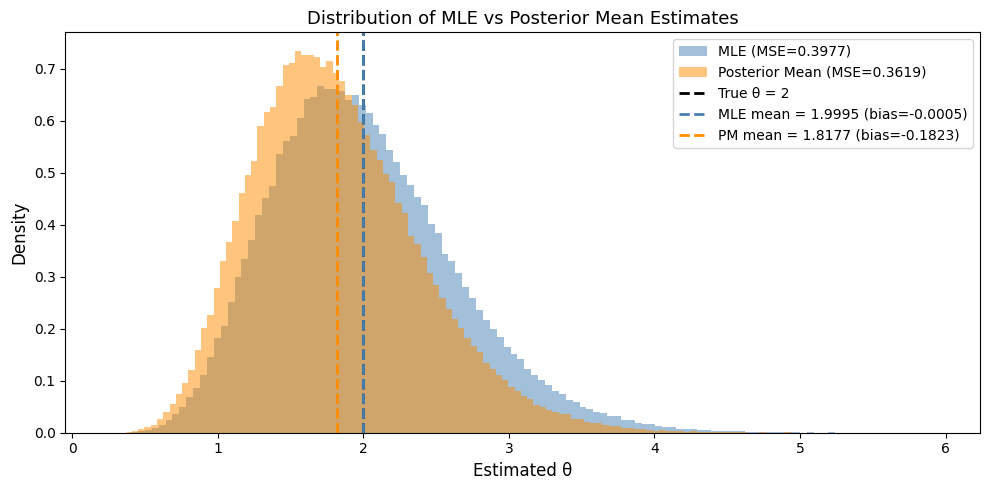

In [4]:
n = 20
n_trials = 200000
true_theta = 2

mle_estimates = []
pm_estimates = []
mle_mses = []
pm_mses = []

for _ in range(n_trials):
    sim_vals = np.random.normal(0, np.sqrt(true_theta), n)
    mle = maximum_likelihood_variance(sim_vals)
    pm = posterior_mean_variance(sim_vals)
    mle_estimates.append(mle)
    pm_estimates.append(pm)
    mle_mses.append((mle - true_theta) ** 2)
    pm_mses.append((pm - true_theta) ** 2)

mle_mse = np.mean(mle_mses)
pm_mse = np.mean(pm_mses)
mle_mean = np.mean(mle_estimates)
pm_mean = np.mean(pm_estimates)

print(f"True theta: {true_theta:.4f}  MLE MSE: {mle_mse:.4f}  PM MSE: {pm_mse:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mle_estimates, bins=120, density=True, color='steelblue', alpha=0.5, label=f'MLE (MSE={mle_mse:.4f})')
ax.hist(pm_estimates,  bins=120, density=True, color='darkorange', alpha=0.5, label=f'Posterior Mean (MSE={pm_mse:.4f})')
ax.axvline(true_theta, color='black', linestyle='--', linewidth=2, label=f'True θ = {true_theta}')
ax.axvline(mle_mean, color='steelblue', linestyle='--', linewidth=2, label=f'MLE mean = {mle_mean:.4f} (bias={mle_mean - true_theta:+.4f})')
ax.axvline(pm_mean,  color='darkorange', linestyle='--', linewidth=2, label=f'PM mean = {pm_mean:.4f} (bias={pm_mean - true_theta:+.4f})')

ax.set_title('Distribution of MLE vs Posterior Mean Estimates', fontsize=13)
ax.set_xlabel('Estimated θ')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

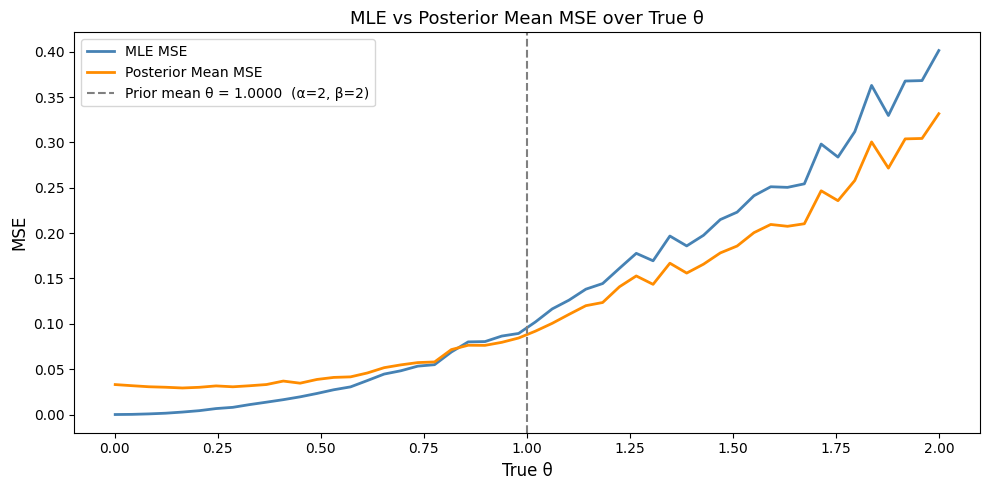

In [37]:
n = 20
n_trials = 1000
alpha_0, beta_0 = 2, 2
prior_mean_theta = beta_0 / (alpha_0 - 1)

true_thetas = np.linspace(0.001, 2.0, 50)

mle_mses = []
pm_mses = []

for true_theta in true_thetas:
    mle_sq_errs = []
    pm_sq_errs = []
    for _ in range(n_trials):
        sim_vals = np.random.normal(0, np.sqrt(true_theta), n)
        mle = maximum_likelihood_variance(sim_vals)
        pm = posterior_mean_variance(sim_vals, alpha=alpha_0, beta=beta_0)
        mle_sq_errs.append((mle - true_theta) ** 2)
        pm_sq_errs.append((pm - true_theta) ** 2)
    mle_mses.append(np.mean(mle_sq_errs))
    pm_mses.append(np.mean(pm_sq_errs))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(true_thetas, mle_mses, color='steelblue', linewidth=2, label='MLE MSE')
ax.plot(true_thetas, pm_mses, color='darkorange', linewidth=2, label='Posterior Mean MSE')
ax.axvline(prior_mean_theta, color='gray', linestyle='--', linewidth=1.5,
           label=f'Prior mean θ = {prior_mean_theta:.4f}  (α={alpha_0}, β={beta_0})')

ax.set_title('MLE vs Posterior Mean MSE over True θ', fontsize=13)
ax.set_xlabel('True θ')
ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()

### 3) Cramer-Rao Lower Bound

The Cramer-Rao Bound tells us that for any unbiased estimator $t$,
$$
\mathrm{Var}[t(x)] \geq \frac{1}{\mathrm{Var}[\ell'_X(\theta)]}
$$
In other words, the lower bound is $\frac{1}{\mathrm{Var}[\ell'(\theta)]} = -\frac{1}{-\mathbb{E}[\ell''(\theta)]}$.

From earlier, we have
$$ \ell'(\theta) =
- \frac{n}{2 \theta} + \frac{1}{2\theta^2} \sum_{i=1}^n X_i^2 
$$
And so
$$ 
\ell''(\theta) =  \frac{n}{2 \theta^2} - \frac{1}{\theta^3} \sum_{i=1}^n X_i^2 
$$
Taking expected value, we get
$$
\mathbb E[\ell''(\theta)] = \frac{n}{2 \theta^2} - \frac{1}{\theta^3} E[\sum_{i=1}^n X_i^2] 
= \frac{n}{2 \theta^2} - \frac{n\theta}{\theta^3}  
= -\frac{n}{2\theta^2}
$$
And so our CRLB is
$$
\frac{2\theta^2}{n}
$$
This is the same as the variance of our MLE estimator, so the MLE estimator is in fact the best possible unbiased estimator.

### Variance Derivation

We start with MLE 
$$ \hat \theta = \frac{1}{n} \sum X_i^2 $$

\begin{align*} 
    \mathrm{Var}[\hat \theta] 
    &= \mathrm{Var}[\frac{1}{n} \sum X_i^2] \\
    &= \frac{1}{n^2} \mathrm{Var}[\sum X_i^2] \\
    &= \frac{1}{n^2} (\mathbb E[X_i^4] - \mathbb E[X_i^2]^2) \\
    &= \frac{1}{n^2} (\mathbb E[X_i^4] - \theta^2)
\end{align*}

## 4. Asymptotic Distribution of MLE

### 1) Distribution of the MLE

We have our frequentist key terms:
$$
\ell(\tau) = \frac{1}{2} \log \tau - \frac{\tau}{2} X_i^2
$$

$$
\hat \tau = \frac{n}{\sum X_i^2}
$$

So 

$$
\sqrt{n}(\hat \tau - \tau_0) \sim \mathrm{Normal}(0, \frac{1}{\mathrm{Var}[\ell'_{X_1} (\tau_0)]})
$$

Deriving with $\tau$, we get
$$
\ell''(\tau) = -\frac{1}{2 \tau^2} \implies \mathbb E[\ell ''] = -\frac{1}{2 \tau_0^2} = - \mathrm {Var}[\ell']
$$

Plugging in, we get

$$
\sqrt{n}(\hat \tau - \tau_0) \sim \mathrm{Normal}(0, 2 \tau_0^2)
$$

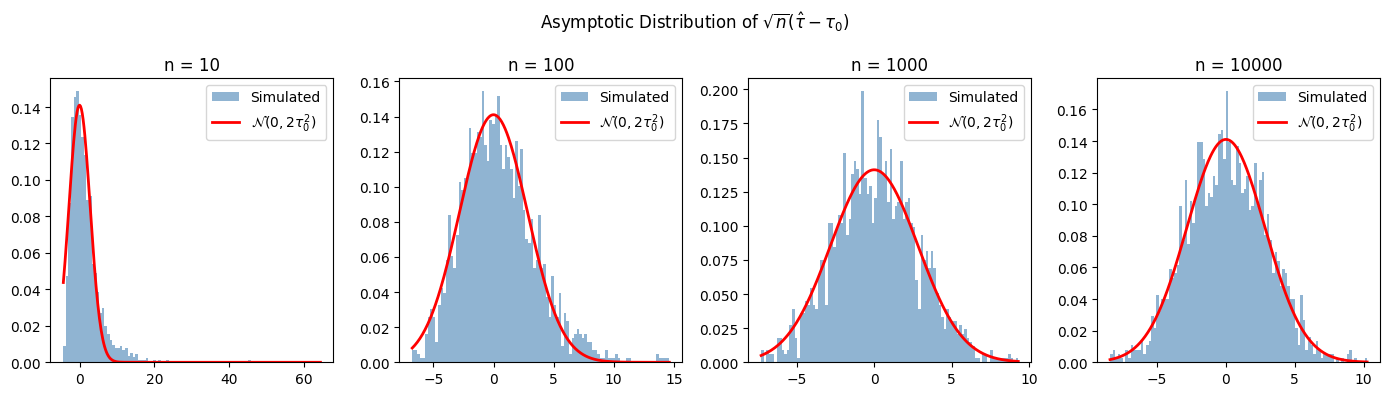

True τ₀ = 2

       n      mean(τ̂)
      10      2.516385
     100      2.042459
    1000      2.004367
   10000      2.000862


In [14]:
tau_0 = 2
mu = 0
n_trials = 2000

sample_sizes = [10, 100, 1000, 10000]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

all_tau_hats = {}

for ax, n in zip(axes, sample_sizes):
    estimates = np.zeros(n_trials)
    tau_hats = np.zeros(n_trials)

    for b in range(n_trials):
        # Step 1: Draw n samples from N(mu, 1/tau_0)
        X = np.random.normal(loc=mu, scale=1/np.sqrt(tau_0), size=n)

        # Step 2: Compute MLE  tau_hat = n / sum((X - mu)^2)
        tau_hat = n / np.sum((X - mu)**2)
        tau_hats[b] = tau_hat

        # Step 3: Compute the centered, scaled quantity
        estimates[b] = np.sqrt(n) * (tau_hat - tau_0)

    all_tau_hats[n] = tau_hats

    # Step 4: Plot histogram
    ax.hist(estimates, bins=100, density=True, alpha=0.6, color='steelblue', label='Simulated')

    # Step 5: Overlay theoretical limit N(0, 2*tau_0^2)
    asymp_var = 2 * tau_0**2
    x = np.linspace(estimates.min(), estimates.max(), 300)
    ax.plot(x, stats.norm.pdf(x, 0, np.sqrt(asymp_var)),
            'r-', lw=2, label=r'$\mathcal{N}(0, 2\tau_0^2)$')

    ax.set_title(f'n = {n}')
    ax.legend()

plt.suptitle(r'Asymptotic Distribution of $\sqrt{n}(\hat\tau - \tau_0)$')
plt.tight_layout()
plt.show()

print(f"True τ₀ = {tau_0}")
print(f"\n{'n':>8}  {'mean(τ̂)':>12}")
for n, tau_hats in all_tau_hats.items():
    print(f"{n:>8}  {np.mean(tau_hats):>12.6f}")

## 5. Confidence and Credible Intervals

### Frequentist -- Confidence Intervals

Recall our key terms:

$$
\ell(\tau) = \frac{1}{2} \log \tau - \frac{\tau}{2} X_i^2
$$

$$
\hat \tau = \frac{n}{\sum X_i^2}
$$

$$
\mathbb E[\ell ''] = -\frac{1}{2 \tau_0^2} = - \mathrm {Var}[\ell']
$$

$$
\hat \tau \sim \mathrm{Normal}(\tau, \frac{2\tau^2}{n})
$$

Strategy 1: CI with plug-in Fisher information

$$
\hat \tau \sim \mathrm{Normal}(\tau, \frac{2\tau^2}{n}) 
$$

So

$$
\tau = \hat \tau \pm 2\sqrt{\frac {2 \tau^2}{n}}
$$

Since the standard error $\sqrt{2\tau^2/n}$ contains $\tau$, we substitute with $\hat \tau$.

$$
\tau = \hat \tau \pm 2\sqrt{\frac {2 \hat \tau^2}{n}}
$$

So we have confidence bounds
$$
\hat \tau - 2 \hat \tau \sqrt{\frac {2}{n}} \leq \tau \leq \hat \tau + 2 \hat \tau \sqrt{\frac {2}{n}}
$$

<!-- $$
\hat \tau (1 - 2 \sqrt{\frac{2}{n}}) \leq \tau \leq \hat \tau (1 + 2 \sqrt{\frac{2}{n}})
$$ -->


Strategy 2: CI with exact Fisher information

Suppose we don't substitute $\tau = \hat \tau$. Then we have 

$$
-2 \leq \frac{\hat \tau - \tau}{\tau \sqrt{2/n}} \leq 2
$$

$$
-2 \sqrt{\frac{2}{n}} \leq \frac{\hat \tau - \tau}{\tau} \leq 2 \sqrt{\frac{2}{n}}
$$

$$
-2 \sqrt{\frac{2}{n}} \leq \frac{\hat \tau}{\tau} - 1 \leq 2 \sqrt{\frac{2}{n}}
$$

$$
1-2 \sqrt{\frac{2}{n}}  \leq \frac{\hat \tau}{\tau} \leq 1 + 2 \sqrt{\frac{2}{n}} 
$$

$$
\frac{\hat \tau}{1+2 \sqrt{\frac{2}{n}}}  \leq \tau \leq \frac{\hat \tau}{1 - 2 \sqrt{\frac{2}{n}} }
$$

$$
\frac{\hat \tau}{1+\sqrt{8 / n}}  \leq \tau \leq \frac{\hat \tau}{1 - \sqrt{ 8 / n}} 
$$





### Bayesian -- Credible Interval

Recall our posterior distribution: 

$$
\tau | x \sim \Gamma (\alpha + \frac{n}{2}, \beta + \frac{\sum X_i^2}{2})
$$



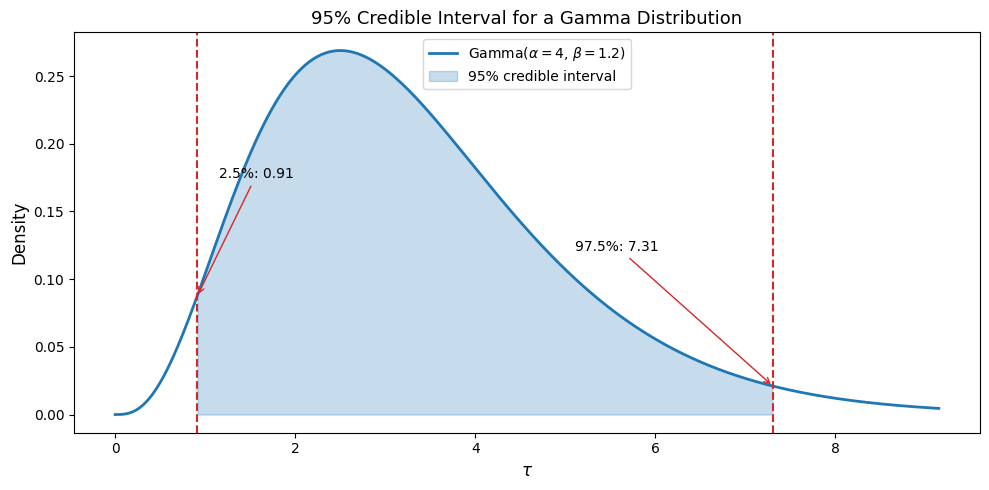

In [4]:
# 95% credible interval on a Gamma distribution

alpha = 4
beta = 1.2  # rate parameter
scale = 1 / beta

lower, upper = stats.gamma.ppf([0.025, 0.975], a=alpha, scale=scale)
x = np.linspace(0, stats.gamma.ppf(0.995, a=alpha, scale=scale), 1000)
pdf = stats.gamma.pdf(x, a=alpha, scale=scale)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, pdf, color="#1f77b4", linewidth=2, label=fr"Gamma($\alpha={alpha}$, $\beta={beta}$)")

inside = (x >= lower) & (x <= upper)
ax.fill_between(x[inside], pdf[inside], color="#1f77b4", alpha=0.25, label="95% credible interval")
ax.axvline(lower, color="#d62728", linestyle="--", linewidth=1.5)
ax.axvline(upper, color="#d62728", linestyle="--", linewidth=1.5)

ax.annotate(fr"2.5%: {lower:.2f}", xy=(lower, stats.gamma.pdf(lower, a=alpha, scale=scale)),
            xytext=(lower + 0.25, pdf.max() * 0.65), arrowprops={"arrowstyle": "->", "color": "#d62728"})
ax.annotate(fr"97.5%: {upper:.2f}", xy=(upper, stats.gamma.pdf(upper, a=alpha, scale=scale)),
            xytext=(upper - 2.2, pdf.max() * 0.45), arrowprops={"arrowstyle": "->", "color": "#d62728"})

ax.set_title("95% Credible Interval for a Gamma Distribution", fontsize=13)
ax.set_xlabel(r"$\tau$", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# 95% confidence intervals for tau = 1 / sigma^2

x = np.asarray(log_returns).squeeze()
n = len(x)
sum_sq = np.sum(x ** 2)
tau_hat = n / sum_sq

z = stats.norm.ppf(0.975)
se_tau_hat = tau_hat * np.sqrt(2 / n)

wald_ci = np.array([
    tau_hat - z * se_tau_hat,
    tau_hat + z * se_tau_hat,
])

inverted_wald_ci = np.array([
    tau_hat / (1 + z * np.sqrt(2 / n)),
    tau_hat / (1 - z * np.sqrt(2 / n)),
])

# Since tau * sum(X_i^2) has a chi-square distribution with n df.
chi_square_ci = stats.chi2.ppf([0.025, 0.975], df=n) / sum_sq

# Bayesian posterior: tau | x ~ Gamma(alpha + n/2, beta + sum(x_i^2)/2)
# Here beta is the rate parameter, so scipy's scale is 1 / beta.
prior_alpha = 2
prior_beta = 0.0002
posterior_alpha = prior_alpha + n / 2
posterior_beta = prior_beta + 0.5 * sum_sq
posterior_mean_tau = posterior_alpha / posterior_beta
posterior_ci = stats.gamma.ppf(
    [0.025, 0.975],
    a=posterior_alpha,
    scale=1 / posterior_beta,
)

def variance_ci(tau_ci):
    return np.array([1 / tau_ci[1], 1 / tau_ci[0]])

print(f"tau_hat: {tau_hat:.4f}")
print(f"Wald 95% CI for tau: [{wald_ci[0]:.4f}, {wald_ci[1]:.4f}]")
print(f"Inverted-Wald 95% CI for tau: [{inverted_wald_ci[0]:.4f}, {inverted_wald_ci[1]:.4f}]")
print(f"Chi-square 95% CI for tau: [{chi_square_ci[0]:.4f}, {chi_square_ci[1]:.4f}]")
print(f"Posterior Gamma shape alpha: {posterior_alpha:.4f}")
print(f"Posterior Gamma rate beta: {posterior_beta:.8f}")
print(f"Posterior mean for tau: {posterior_mean_tau:.4f}")
print(f"Posterior 95% credible interval for tau: [{posterior_ci[0]:.4f}, {posterior_ci[1]:.4f}]")

print("\nOn the variance scale, sigma^2 = 1 / tau:")
for label, tau_ci in [
    ("Wald", wald_ci),
    ("Inverted-Wald", inverted_wald_ci),
    ("Chi-square", chi_square_ci),
    ("Posterior", posterior_ci),
]:
    sigma2_ci = variance_ci(tau_ci)
    print(f"{label} 95% CI for sigma^2: [{sigma2_ci[0]:.8f}, {sigma2_ci[1]:.8f}]")


tau_hat: 6699.9624
Wald 95% CI for tau: [6470.2702, 6929.6545]
Inverted-Wald 95% CI for tau: [6477.8836, 6937.8085]
Chi-square 95% CI for tau: [6472.2178, 6931.5899]
Posterior Gamma shape alpha: 3270.5000
Posterior Gamma rate beta: 0.48803856
Posterior mean for tau: 6701.3147
Posterior 95% credible interval for tau: [6473.5933, 6932.9175]

On the variance scale, theta = sigma^2 = 1 / tau:
Wald 95% CI for sigma^2: [0.00014431, 0.00015455]
Inverted-Wald 95% CI for sigma^2: [0.00014414, 0.00015437]
Chi-square 95% CI for sigma^2: [0.00014427, 0.00015451]
Posterior 95% CI for sigma^2: [0.00014424, 0.00015447]


## 6. Simulating Confidence Intervals 

In [13]:
# Setup

alpha_prior = 2.0
beta_prior = 0.0002
mu = 0

def mle(x):
    x = np.asarray(x).squeeze()
    return len(x) / np.sum(x ** 2)

def log_posterior(tau, data, mu0, alpha_prior=2, beta_prior=0.0002):
    if tau <= 0:
        return -np.inf 
    data = np.asarray(data).squeeze()
    n = len(data)
    ss = np.sum((data - mu0) ** 2)
    log_lik = (n/2)*np.log(tau) - (tau/2)*ss 
    log_prior = (alpha_prior-1)*np.log(tau) - beta_prior*tau 
    return log_lik + log_prior


def plot_quantile_hist(values, bins=30, title=None, ax=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    q025, q975 = np.quantile(values, [0.025, 0.975])

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    ax.hist(values, bins=bins, alpha=0.7, color="steelblue", edgecolor="white")
    ax.axvline(q025, color="crimson", linestyle="--", linewidth=2, label="0.025 quantile")
    ax.axvline(q975, color="crimson", linestyle="--", linewidth=2, label="0.975 quantile")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.set_title(title or "Histogram with 95% Quantile Interval")
    ax.legend()

    print(f"0.025 quantile: {q025:.6g}")
    print(f"0.975 quantile: {q975:.6g}")
    plt.show()

    return q025, q975

### Frequentist — Parameter Bootstrapping

Core idea: we treat $\hat \tau = \tau$ and simulate using the estimated **parameter** as the true one. Then we calculate a confidence interval on simulated $\hat \tau ^*$. 

0.025 quantile: 6470.49
0.975 quantile: 6938.75


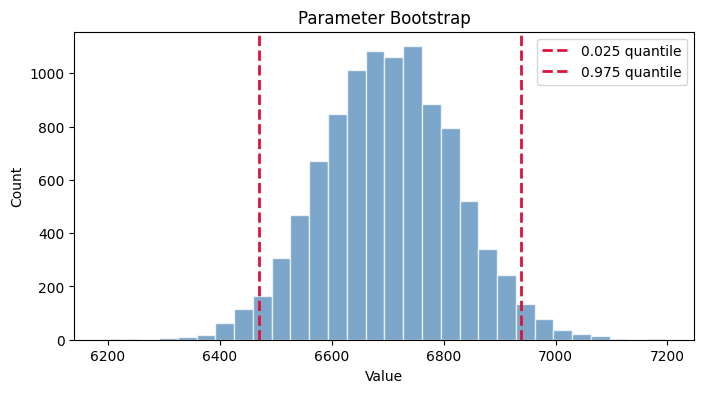

(np.float64(6470.48768515488), np.float64(6938.754957505388))

In [ ]:
# np.random.normal(loc= , scale= , size= )
n_trials = 10000
data = np.asarray(log_returns).squeeze()
n = len(data)

tau_mle = mle(data)
sim_pboot = np.empty(n_trials)

for i in range(n_trials):
    # generate data with tau_mle
    sim_data = np.random.normal(loc=mu, scale=np.sqrt(1/tau_mle), size=n)
    # calculate simulation mle for each simulation
    sim_pboot[i] = mle(sim_data)

# plot and find confidence interval
plot_quantile_hist(sim_pboot, title="Parameter Bootstrap")

### Frequentist — Nonparametric Bootstrapping

Core idea: take samples directly from the data, WITH REPLACEMENT, making no assumptions about the shape of the data-generating distribution

In [ ]:
n_trials = 10
n = len(log_returns)
data = np.asarray(log_returns).squeeze()

all_samples = np.random.choice(data, size=(n_trials, n), replace=True)
sim_npboot = mle(all_samples)

# plot and find confidence interval
plot_quantile_hist(sim_npboot, title="Nonparametric Bootstrap")

AttributeError: 'DataFrame' object has no attribute 'flatten'

### Bayesian — Metropolis-Hastings

We follow the following process:
1. Propose value $\tau^{(i)}$ from some distribution $g$. Generally, $g \sim N(\tau^{(i - 1)}, Var)$
2. Keep $\alpha^i$ with probability $\mathrm{min} (\frac{f(\tau^{(i)})}{f(\tau^{(i - 1)})} , 1)$, otherwise keep $\tau^{(i)}$, append to list
3. Repeat for some number of iterations, then use last K samples as simulation distribution

0.025 quantile: 6469.93
0.975 quantile: 6920.47


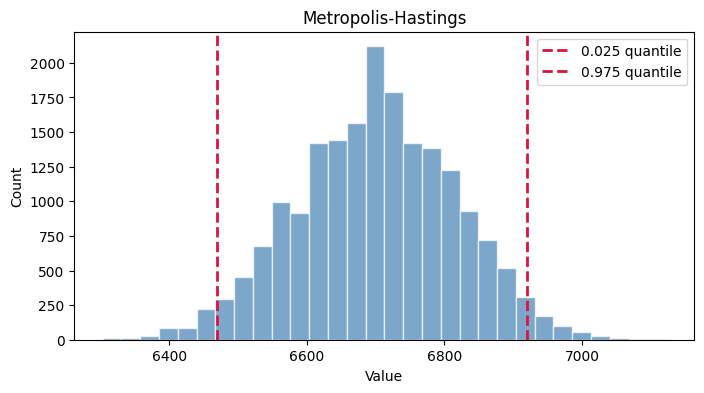

(np.float64(6469.928393497574), np.float64(6920.4712010521935))

In [15]:
n_iter = 20000
burn_in = 1000
# np.random.normal(loc= , scale= , size= )

sampled_tau = []
tau_current = tau_mle
log_p_current = log_posterior(tau_current, np.asarray(log_returns).squeeze(), mu)
proposal_sd = 0.1 * tau_current

for _ in range(n_iter):
    # propose new tau
    tau_proposed = np.random.normal(tau_current, proposal_sd)
    log_p_proposed = log_posterior(tau_proposed, np.asarray(log_returns).squeeze(), mu)

    # accept with probability min(1, f(tau)/f(tau_proposed))
    alpha = min(1, np.exp(log_p_proposed - log_p_current))
    if np.random.uniform() < alpha:
        tau_current = tau_proposed
        log_p_current = log_p_proposed

    sampled_tau.append(tau_current)

# plot and find confidence interval
plot_quantile_hist(sampled_tau[:-burn_in], title="Metropolis-Hastings")



### Comparison

Key parameters

| Quantity | Value |
| --- | ---: |
| MLE tau | 6699.9624 |
| Posterior Gamma shape alpha | 3270.5000 |
| Posterior Gamma rate beta | 0.48803856 |
| Posterior mean for tau | 6701.3147 |

Intervals

| Interval | Lower | Upper |
| --- | ---: | ---: |
| Approx 95% CI for tau via substitution | 6470.2702 | 6929.6545 |
| Exact 95% CI for tau via inversion | 6477.8836 | 6937.8085 |
| Posterior 95% CI | 6473.5933 | 6932.9175 |
| Parameter Bootstrap CI |  |  |
| Nonparametric Bootstrap CI |  |  |
| Metropolis-Hastings CI |  |  |

## 7. Hypothesis Testing

We have the objective:

$$
\max \beta s.t. 
$$

## 8. Generalized Likelihood Ratio Test

Continuing the hypothesis test that you did last week, derive the generalized likelihood ratio test for 
- $H_0: \tau = \tau_0$
- $H_A: \tau \neq \tau_0$

If possible, try to simplify the generalized likelihood ratio test statistic and obtain an exact test. If not, use Wilks' theorem to obtain an approximate test.

See if you can plot the power curve as a function of values of $\tau$ under the alternative hypothesis.

By the Generalized Likelihood Ratio Test, we reject the null hypothesis when

$$
\frac{\max_{\tau} L_{X_1, \ldots, X_n} (\tau)}{L_{X_1, \ldots, X_n} (\tau_0)} \geq c
$$

And we have normal pdf:

$$
\sqrt{\frac{\tau}{2 \pi}} \exp(-\frac \tau2 (x - \mu)^2)
$$

Which makes the GLRT with MLE $\hat \tau = \frac{n}{\sum (x_i - \mu)^2}$:

\begin{align*}
\Lambda
&= 
\frac{(\frac{\hat \tau}{2 \pi})^{n/2} \exp(-\frac {\hat \tau}{2} \sum(x_i - \mu)^2)}
{(\frac{\tau_0}{2 \pi})^{n/2} \exp(-\frac {\tau_0}{2} \sum(x_i - \mu)^2)}\\
&=
\frac{ \hat \tau^{n/2} \exp(-\frac {\hat \tau}{2} \sum(x_i - \mu)^2)}
{ \tau_0^{n/2} \exp(-\frac {\tau_0}{2} \sum(x_i - \mu)^2)} \\
&=
(\frac{\hat \tau}{\tau_0})^{n/2} \exp(-\frac {\hat \tau}{2} \sum(x_i - \mu)^2 + \frac {\tau_0}{2} \sum(x_i - \mu)^2) \\
&= 
(\frac{\hat \tau}{\tau_0})^{n/2} \exp(-\frac{n}{2\sum (x_i - \mu)^2} \sum(x_i - \mu)^2 + \frac {\tau_0}{2} \sum(x_i - \mu)^2) \\
&=
(\frac{\hat \tau}{\tau_0})^{n/2} \exp(-\frac{n}{2} + \frac {\tau_0}{2} \sum(x_i - \mu)^2) \\

\log \Lambda &=
\frac{n}{2} (\log \hat \tau - \log \tau_0) -\frac{n}{2} + \frac {\tau_0}{2} \sum(x_i - \mu)^2 \\

2 \log \Lambda &=
n (\log \hat \tau - \log \tau_0) -n + \tau_0 \sum(x_i - \mu)^2  \\
&=
n (\log \hat \tau - \log \tau_0) -n + n\frac{\tau_0}{\hat \tau} \\
&= 
n(\log \frac{\hat \tau}{\tau_0} + \frac{\tau_0}{\hat \tau} - 1)
\end{align*}

Now, applying Wilks', we get:

$$
\log \Lambda  = n(\log \frac{\hat \tau}{\tau_0} + \frac{\tau_0}{\hat \tau} - 1) \geq \chi^2_1
$$


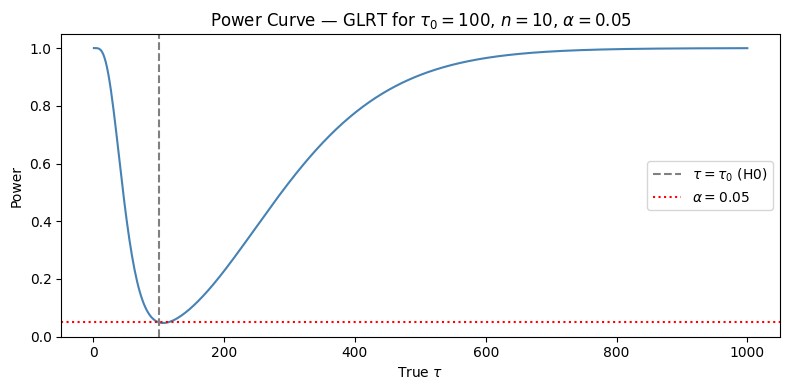

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parameters
n = 10
tau_0 = 100
alpha = 0.05

# Critical values under H0
c1 = chi2.ppf(alpha / 2, df=n)
c2 = chi2.ppf(1 - alpha / 2, df=n)

# Grid of true tau values
tau_grid = np.linspace(1, 1000, 500)

# maybe can use wilks instead of this formula

# Power at each true tau
# t ~ (tau_0/tau) * chi2_n, so rescale critical values by tau/tau_0
def power(tau):
    scale = tau / tau_0
    return chi2.cdf(scale * c1, df=n) + (1 - chi2.cdf(scale * c2, df=n))

pow_vals = [power(tau) for tau in tau_grid]

# Plot
plt.figure(figsize=(8, 4))
plt.plot(tau_grid, pow_vals, color='steelblue')
plt.axvline(tau_0, color='gray', linestyle='--', label=r'$\tau = \tau_0$ (H0)')
plt.axhline(alpha, color='red', linestyle=':', label=rf'$\alpha = {alpha}$')
plt.xlabel(r'True $\tau$')
plt.ylabel('Power')
plt.title(rf'Power Curve — GLRT for $\tau_0={tau_0}$, $n={n}$, $\alpha={alpha}$')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Bayesian Hypothesis Testing & Bayes Factor

$H_0: \tau = \tau_0$

$H_A: \tau = \tau_A$

$$
\frac{P(H_A | X)}{P(H_0 | X)} * \frac{P(H_A)}{P(H_0)}
$$
Suppose $P(H_A) = 0.9$, $P(H_0) = 0.1$
$$
\frac{P(H_A | X)}
{ \prod \sqrt{\frac{\tau_0}{2 \pi}} \exp(-\frac {\tau_0}{2} (x - \mu)^2)} 
* \frac{0.9}{0.1}
$$

$$
\frac{
    \int_0^\infty
    \bigg( (\frac{\tau}{2 \pi})^{n/2} \exp(-\frac {\tau}{2} \sum (x_i - \mu)^2) \bigg)
    \bigg ( \frac{\beta^\alpha}{\Gamma(\alpha)} 
    \tau^{\alpha - 1} \exp(- \beta \tau) \bigg) d \tau
}
{ (\frac{\tau_0}{2 \pi})^{n/2} \exp(-\frac {\tau_0}{2} \sum (x_i - \mu)^2)} 
* 9
$$

$$
\frac{
    (2\pi)^{-n/2}
    \frac{\beta^\alpha}{\Gamma(\alpha)} 
    \int_0^\infty
    \bigg( (\tau)^{\alpha + n/2 - 1} \exp(- \tau ( \beta + \frac {1}{2} \sum (x_i - \mu)^2) ) \bigg) d \tau
}
{ (\frac{\tau_0}{2 \pi})^{n/2} \exp(-\frac {\tau_0}{2} \sum (x_i - \mu)^2)} 
* 9
$$

$$
\frac{
    (2\pi)^{-n/2}
    \frac{\beta^\alpha}{\Gamma(\alpha)} 
    \frac{\Gamma(\alpha_0 + \frac n2)}{\beta^{\alpha_0 + \frac n2}}
}
{ (\frac{\tau_0}{2 \pi})^{n/2} \exp(-\frac {\tau_0}{2} \sum (x_i - \mu)^2)} 
* 9
$$

$$
\frac{
    \beta^\alpha \Gamma(\alpha + \frac n2)
    \exp(\frac {\tau_0}{2} \sum (x_i - \mu)^2)
}
{ \Gamma(\alpha) \beta^{\alpha + \frac n2} (\tau_0)^{n/2} } 
* 9
$$

